# Rounding error experiments #

This Jupyter notebook contains code to approximate the Wright $\omega$ function iteratively, and samples the function at enough points to examine rounding errors.

To look at different methods, uncomment the corresponding lines in the procedure "gettem", which is compiled for faster execution.  One can sample up to $10^8$ points in about 9 seconds on this machine, but plotting so many points is very slow; so the current code only samples $10^6$ points, most of them being negative.

The rounding error plots look peculiar unless you realize that rounding errors are not random.

© Robert M. Corless 2026 (MIT Release licence)

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.


In [1]:
wom := proc(x) 
  local a_0, a_1, a_2, a_3, a_4, b_0, b_1, b_2, b_3, ex, t44;
  if not type(x,float) then 
    return 'procname'('args') 
  elif x <= -2.0 then
    ex := exp(x);
    return (1+(-1+(3/2+(-8/3+(125/24+
           (-54/5+16807/720*ex)*ex)*ex)*ex)*ex)*ex)*ex;
  elif x <= 14.0 then
    a_0 := 0.539453606230641:
    a_1 := 0.506797986811709:
    a_2 := 0.208228149724299:
    a_3 := 0.0440112471100988:
    a_4 := 0.00400140172512448:
    b_0 := 0.951137908021286:
    b_1 := 0.286508942892132:
    b_2 := 0.0607933683264613:
    b_3 := 0.00403517599548807:
    return (a_0 + x*(a_1 + x*(a_2 + x*(a_3 + x*a_4))))/
           (b_0 + x*(b_1 + x*(b_2+x*b_3)));
  else
    # Use asymptotic series
    t44 := ln(x);
    return x-t44+t44/x+(-1.0+0.5*t44)*t44/x^2;
  end if;
end proc:


kilobytes used=747, alloc=5168, time=0.17

In [2]:
S4 := proc(x)
  local s, w0;
  w0 := wom(x);
  s := x - w0 - ln(w0);
  return w0 + s/(1/w0*(w0+1)+s/(-2*w0*(w0+1)-1/3*s/(w0+1)*w0*(4*w0+1)));
end proc:

In [3]:
S3 := proc(x)
  local s, w0;
  w0 := wom(x);
  s := x - w0 - ln(w0);
  return w0 + s/(1/w0*(w0+1)-1/2*s/w0/(w0+1));
end proc:

In [4]:
gettem := proc( L, U, N, refs, hex, why )
  local a_0, a_1, a_2, a_3, a_4, b_0, b_1, b_2, b_3, t44, t94, t95, i, r, s, ex, x, w0;
  a_0 := 0.539453606230641:
  a_1 := 0.506797986811709:
  a_2 := 0.208228149724299:
  a_3 := 0.0440112471100988:
  a_4 := 0.00400140172512448:
  b_0 := 0.951137908021286:
  b_1 := 0.286508942892132:
  b_2 := 0.0607933683264613:
  b_3 := 0.00403517599548807:

  for i to N do
    refs[i] := 10.0^(L+(U-L)*(i-1.0)/(N-1.0));
    hex[i] := ln(refs[i]) + refs[i];
    x := hex[i];
    if x <= -2.0 then
      ex := exp(x);
      w0 := (1+(-1+(3.0/2.0+(-8.0/3.0+(125.0/24.0+
           (-54.0/5.0+16807.0/720.0*ex)*ex)*ex)*ex)*ex)*ex)*ex;
    elif x <= 14.0 then
      w0 := (a_0 + x*(a_1 + x*(a_2 + x*(a_3 + x*a_4))))/
           (b_0 + x*(b_1 + x*(b_2+x*b_3)));
    else 
      t44 := ln(x);
      w0 := x-t44+t44/x+(-1.0+0.5*t44)*t44/x^2;
    end if;
    s := x - w0 - ln(w0);
    # Halley
    why[i] := w0 + s/(1.0/w0*(w0+1)-1.0/2.0*s/w0/(w0+1.0));
    # Householder 4
    # why[i] := w0 + s/(1.0/w0*(w0+1)+s/(-2.0*w0*(w0+1.0)-1.0/3.0*s/(w0+1)*w0*(4.0*w0+1.0)));
    # Two Newton steps
    # w0 := w0 + s/(1.0+1.0/w0);
    # s := x - w0 - ln(w0);
    # why[i] := w0 + s/(1.0+1.0/w0);
    # Schroeder 4
    # r := w0 + ln(w0) - x;
    # t94 := w0+1.0; 
    # t95 := t94^2; 
    # why[i] :=  w0-1.5*w0*r*(r+2.0*t95)/(3.0*t95*t94+(3.0*t94+r)*r) 
  end do;
end proc:

In [5]:
cg := Compiler:-Compile(gettem);

kilobytes used=4788, alloc=10801, time=0.50

proc () options call_external, define_external(maple_compiled_mf3cfe35a36df1e49d905baeacd49a815,MAPLE,LIB = "C:\\Users\\rcorl\\AppData\\Local\\Temp\\rcorl-8852\\maple_compiled_mf3cfe35a36df1e49d905baeacd49a815yYxVbxdp.dll"); call_external(0,140724083496944,true,false,false,_passed) end proc

In [6]:
L := -12:
U := 3:
N := 10^6:
dt := float[8]:
refs := Array( 1..N,  datatype=dt):
hex := Array( 1..N, datatype=dt ):
why := Array( 1..N, datatype=dt ):
st := time():
#evalhf(gettem(L,U,N,refs,hex,why)):
cg(L,U,N,refs,hex,why):
time_taken := time()-st;

$$ 0.094$$

In [7]:
abserr := Array(1..N, i->why[i]-refs[i]):

In [8]:
ii := max[index](map(abs,abserr));

$$980620$$

In [9]:
abserr[ii];

$$-{ 1.13686837721616030\times 10^{-13}}$$

In [10]:
hex[ii];

$$ 518.273465324377867$$

In [11]:
why[ii];

$$ 512.035072201291200$$

In [12]:
refs[ii];

$$ 512.035072201291314$$

In [13]:
Digits := 30:
ref30 := Wrightomega(hex[ii]);

$$ 512.035072201291257023467838564$$

In [14]:
refs[ii]-ref30;

$${ 5.6976532161436\times 10^{-14}}$$

In [15]:
Digits := 15:
relerr := Array(1..N, i->abserr[i]/refs[i]):
jj := max[index](map(abs,relerr));

$$769033$$

In [16]:
relerr[jj];

$${ 3.04121096684286210\times 10^{-14}}$$

In [17]:
hex[jj];

$$- 0.726414314411082840$$

In [18]:
why[jj];

$$ 0.343155951535670523$$

In [19]:
refs[jj];

$$ 0.343155951535660086$$

In [20]:
Digits := 30:
ref30jj := Wrightomega(hex[jj]);

$$ 0.343155951535660124087518099775$$

In [21]:
(refs[jj]-ref30jj)/ref30jj;

$$-{ 1.10991862240270707995595500798\times 10^{-16}}$$

In [22]:
(why[jj]-ref30jj)/ref30jj*2^54;

$$ 545.903845396981300188031485875$$

In [23]:
Digits := 15:
refs[jj] + ln(refs[jj]) - hex[jj];

$$ 0.0$$

In [24]:
hex[1];

$$- 27.6310211159275489$$

In [25]:
hex[10^5];

$$- 24.1771745613356970$$

In [26]:
okthen := solve( L + (U-L)*(ind-1)/(N-1) = 0, ind );

$${\frac{4000001}{5}}$$

In [27]:
Nd := floor(okthen);

$$800000$$

kilobytes used=23053, alloc=31315, time=2.70

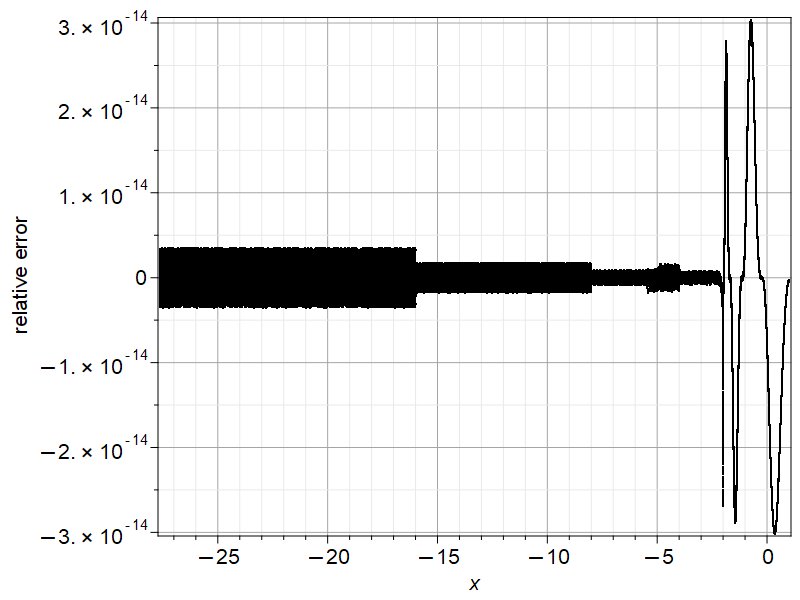

In [28]:
plots[pointplot]( [seq([hex[i],relerr[i]], i=1..Nd)], 
style=point, symbol=point, gridlines, labels=[x,"relative error"], labeldirections=[horizontal,vertical] );

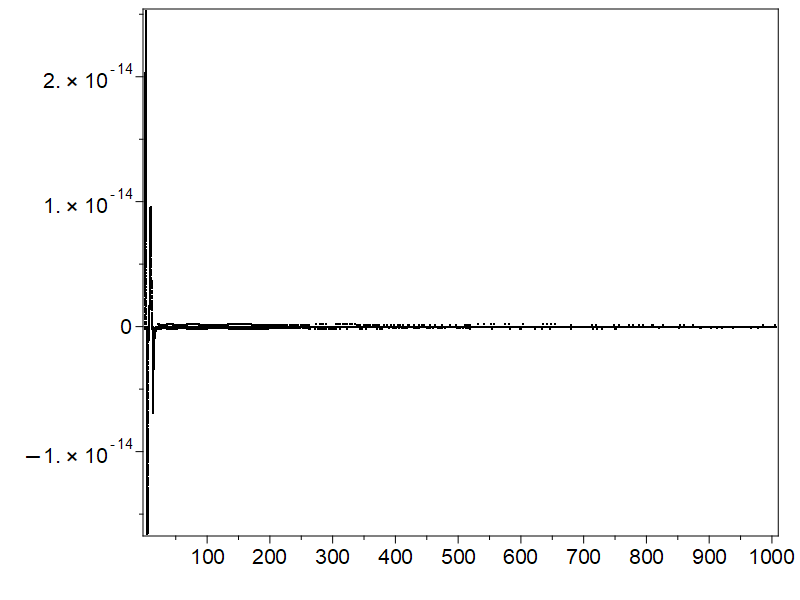

In [29]:
plots[pointplot]( [seq([hex[i],relerr[i]], i=Nd+1..N)], 
style=point, symbol=point );

kilobytes used=43404, alloc=37365, time=4.76

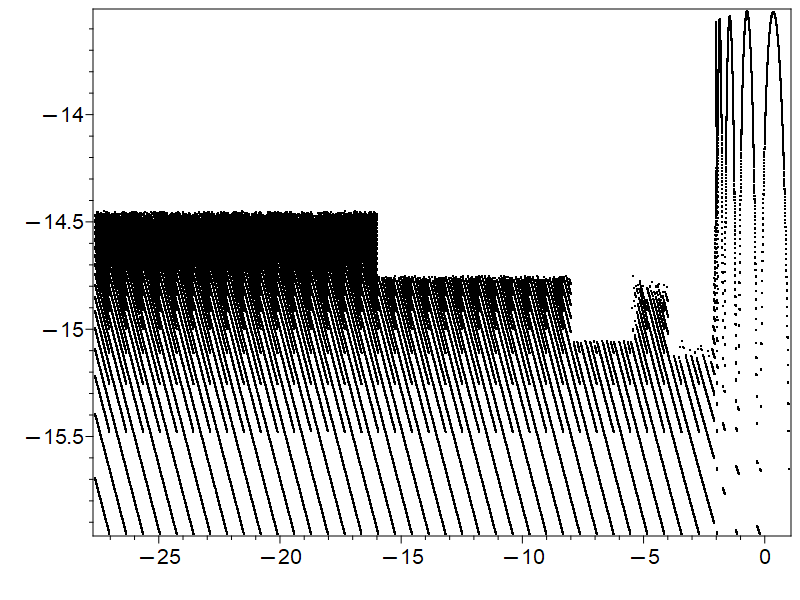

In [30]:
plots[pointplot]( [seq([hex[i],log10(abs(relerr[i]))], i=1..Nd)], 
style=point, symbol=point );

kilobytes used=54974, alloc=38342, time=6.94

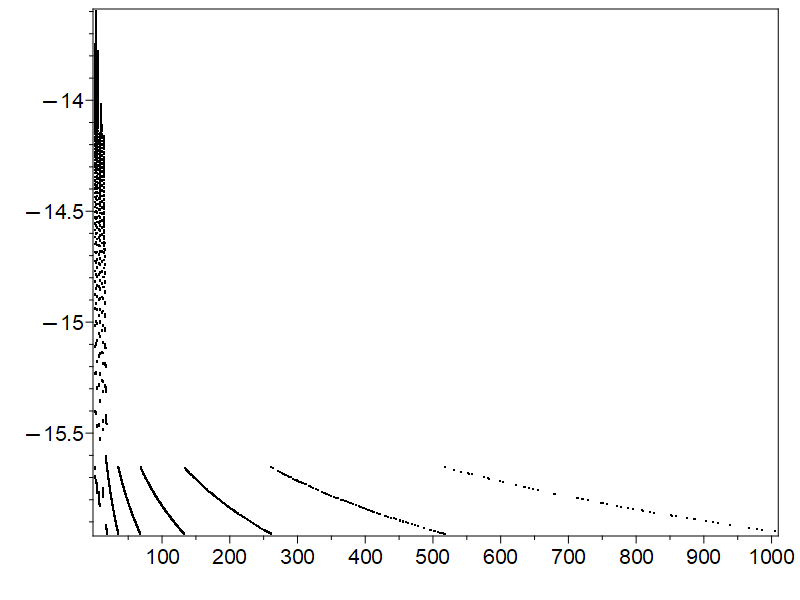

In [31]:
plots[pointplot]( [seq([hex[i],log10(abs(relerr[i]))], i=Nd+1..N)], 
style=point, symbol=point );